<a href="https://colab.research.google.com/github/Prathama-1/Prosperity-4---Solo42/blob/main/Round4_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ─── CELL 1: Installs & Imports ────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import norm, pearsonr
from scipy.optimize import brentq
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120

In [2]:
# ─── CELL 2: Load Data ─────────────────────────────────────────────────────

p1 = pd.read_csv("prices_round_4_day_1.csv", sep=";")
p2 = pd.read_csv("prices_round_4_day_2.csv", sep=";")
p3 = pd.read_csv("prices_round_4_day_3.csv", sep=";")
t1 = pd.read_csv("trades_round_4_day_1.csv", sep=";")
t2 = pd.read_csv("trades_round_4_day_2.csv", sep=";")
t3 = pd.read_csv("trades_round_4_day_3.csv", sep=";")

t1["day"] = 1; t2["day"] = 2; t3["day"] = 3
prices = pd.concat([p1, p2, p3], ignore_index=True)
trades = pd.concat([t1, t2, t3], ignore_index=True)

# Create a global time index  (day * 1_000_000 + timestamp)
prices["global_ts"] = prices["day"] * 1_000_000 + prices["timestamp"]
trades["global_ts"] = trades["day"] * 1_000_000 + trades["timestamp"]

PRODUCTS   = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]
VEV_STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VEV_NAMES   = [f"VEV_{k}" for k in VEV_STRIKES]
ALL_MARKS   = sorted(set(trades["buyer"].unique()) | set(trades["seller"].unique()))

print("Products in prices:", prices["product"].unique().tolist())
print("Unique Marks:", ALL_MARKS)
print(f"Price rows: {len(prices):,}   Trade rows: {len(trades):,}")

Products in prices: ['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK', 'VEV_6000', 'VEV_5000', 'VEV_6500', 'VEV_5300', 'VEV_5400', 'VEV_4000', 'VEV_5100', 'VEV_5200', 'VEV_5500', 'VEV_4500']
Unique Marks: ['Mark 01', 'Mark 14', 'Mark 22', 'Mark 38', 'Mark 49', 'Mark 55', 'Mark 67']
Price rows: 360,000   Trade rows: 4,281



=== MID PRICE STATS PER PRODUCT ===
                        mean    std     min      max
product                                             
HYDROGEL_PACK        9994.65  34.62  9891.0  10081.0
VELVETFRUIT_EXTRACT  5247.65  18.08  5191.5   5300.0
VEV_4000             1247.66  18.10  1189.0   1302.0
VEV_4500              747.66  18.09   690.5    800.5
VEV_5000              251.14  17.46   196.5    301.5
VEV_5100              160.86  16.13   111.5    205.5
VEV_5200               88.99  13.35    51.0    122.5
VEV_5300               41.18   9.14    18.0     61.0
VEV_5400               12.63   4.15     3.5     23.0
VEV_5500                4.71   2.21     0.5     10.0
VEV_6000                0.50   0.00     0.5      0.5
VEV_6500                0.50   0.00     0.5      0.5


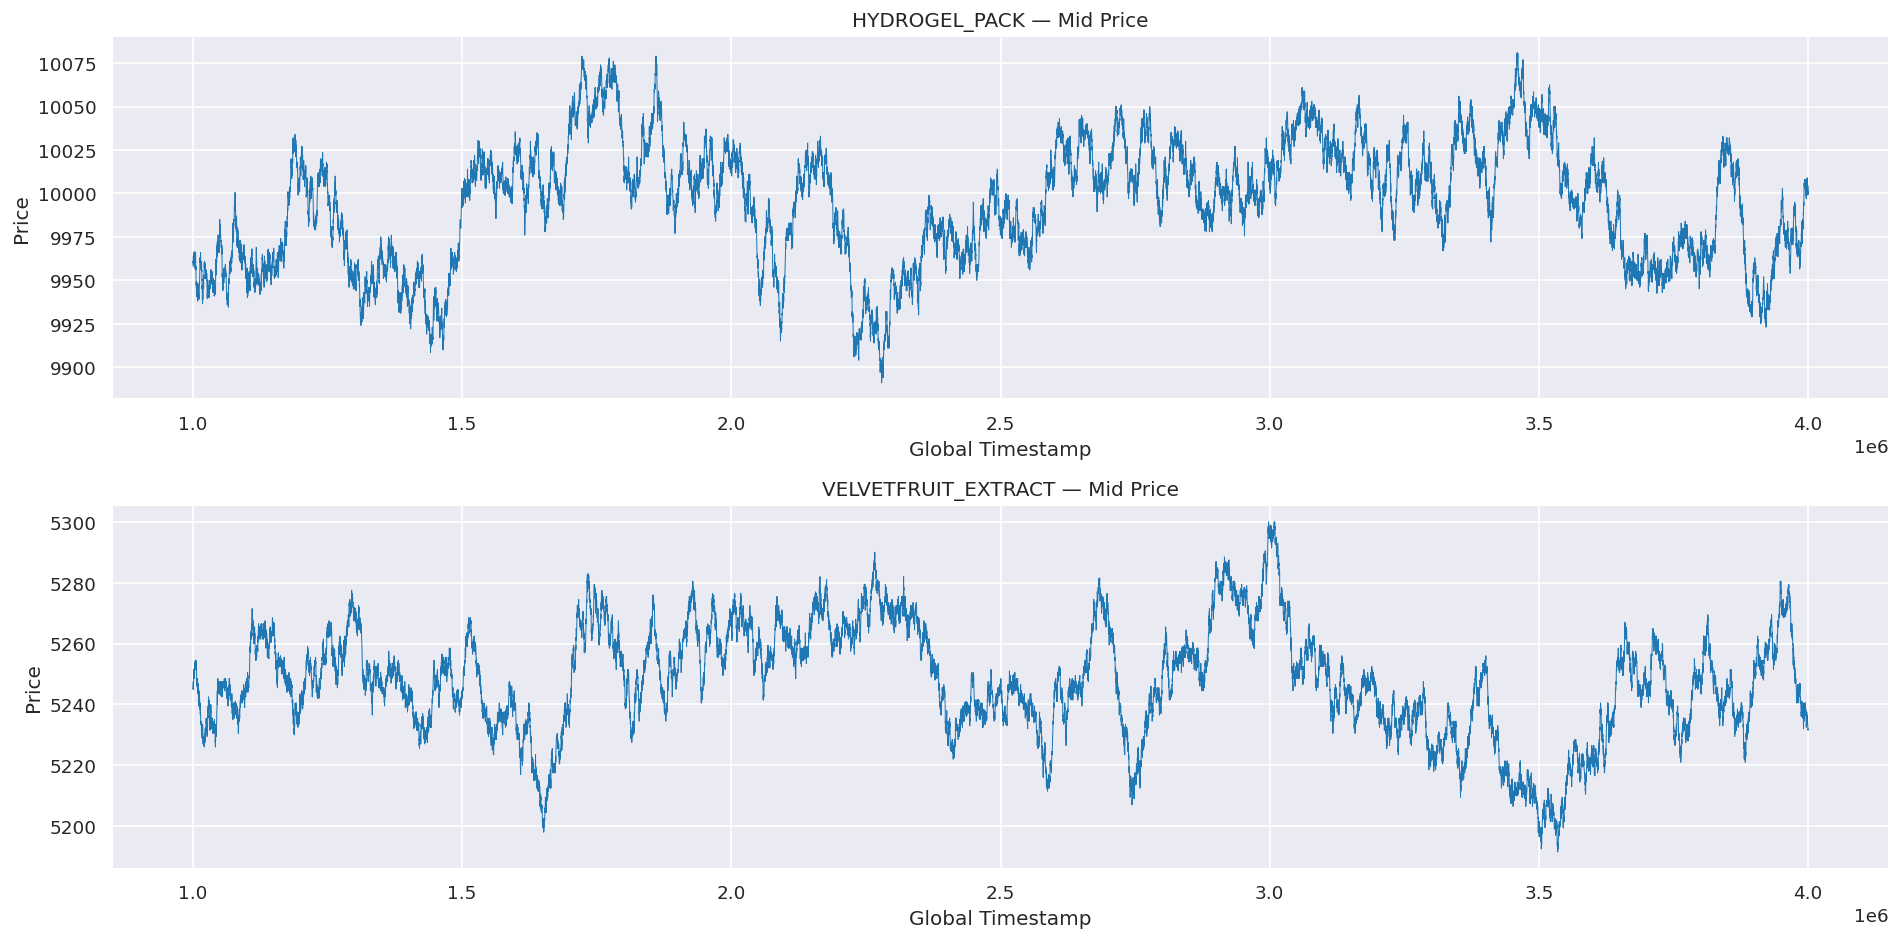

In [3]:
# ─── CELL 3: Price Overview ────────────────────────────────────────────────
print("\n=== MID PRICE STATS PER PRODUCT ===")
print(prices.groupby("product")["mid_price"]
      .agg(["mean", "std", "min", "max"]).round(2).to_string())

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)
for ax, prod in zip(axes, ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]):
    df = prices[prices["product"] == prod].sort_values("global_ts")
    ax.plot(df["global_ts"], df["mid_price"], linewidth=0.6)
    ax.set_title(f"{prod} — Mid Price")
    ax.set_xlabel("Global Timestamp"); ax.set_ylabel("Price")
plt.tight_layout(); plt.show()

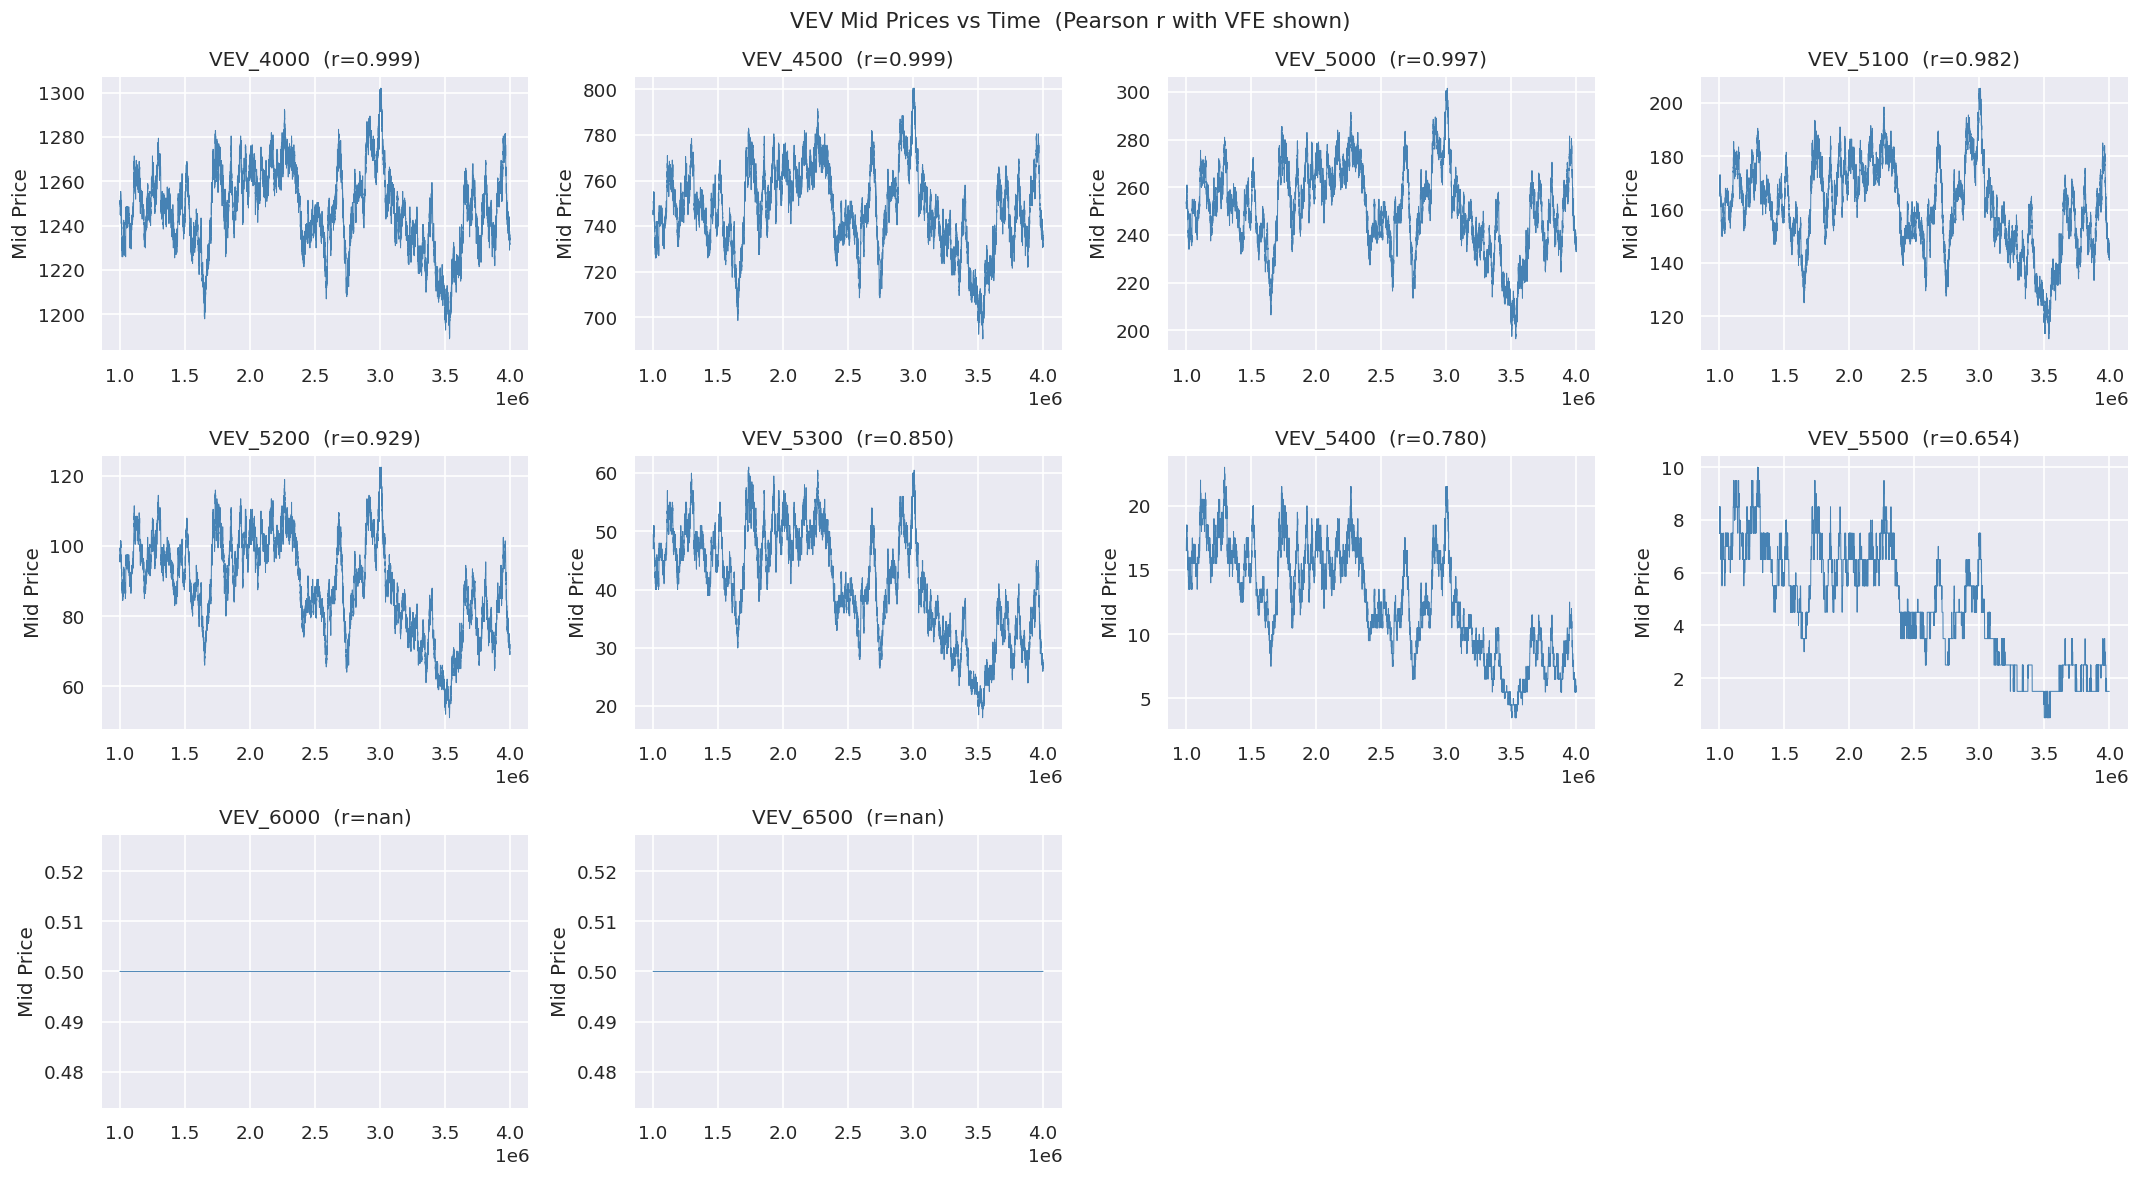


=== VFE vs VEV Pearson r ===
  VEV_4000: r = 0.9989
  VEV_4500: r = 0.9991
  VEV_5000: r = 0.9969
  VEV_5100: r = 0.9818
  VEV_5200: r = 0.9287
  VEV_5300: r = 0.8500
  VEV_5400: r = 0.7796
  VEV_5500: r = 0.6541
  VEV_6000: r = nan
  VEV_6500: r = nan


In [4]:
# ─── CELL 4: VEV Mid Prices + Correlation with VFE ────────────────────────
vfe_ts = (prices[prices["product"] == "VELVETFRUIT_EXTRACT"]
          .sort_values("global_ts")[["global_ts", "mid_price"]]
          .rename(columns={"mid_price": "vfe"}))

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()
for i, K in enumerate(VEV_STRIKES):
    vev_ts = (prices[prices["product"] == f"VEV_{K}"]
              .sort_values("global_ts")[["global_ts", "mid_price"]]
              .rename(columns={"mid_price": f"vev_{K}"}))
    m = vfe_ts.merge(vev_ts, on="global_ts")
    axes[i].plot(m["global_ts"], m[f"vev_{K}"], linewidth=0.6, color="steelblue")
    r, _ = pearsonr(m["vfe"], m[f"vev_{K}"])
    axes[i].set_title(f"VEV_{K}  (r={r:.3f})")
    axes[i].set_xlabel(""); axes[i].set_ylabel("Mid Price")
# hide extra subplots
for j in range(i+1, len(axes)): axes[j].set_visible(False)
fig.suptitle("VEV Mid Prices vs Time  (Pearson r with VFE shown)", fontsize=13)
plt.tight_layout(); plt.show()

print("\n=== VFE vs VEV Pearson r ===")
for K in VEV_STRIKES:
    vev_ts = (prices[prices["product"] == f"VEV_{K}"]
              [["global_ts", "mid_price"]].rename(columns={"mid_price": f"vev_{K}"}))
    m = vfe_ts.merge(vev_ts, on="global_ts")
    r, _ = pearsonr(m["vfe"], m[f"vev_{K}"])
    print(f"  VEV_{K}: r = {r:.4f}")
